In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, test_dataset_path, classes, batch_size=64, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Load the test dataset
    test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=classes)

    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print("\nClassification Report:\n", report)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig # pytorch based model
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import kagglehub

import os
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    config=ViTConfig.from_pretrained('google/vit-base-patch16-224-in21k', num_labels=8)
)

model.load_state_dict(torch.load('plastic_predictor.pth', map_location='cpu'))
model.eval()


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

Test Accuracy: 17.66%

Classification Report:
                                    precision    recall  f1-score   support

               1_polyethylene_PET       0.18      1.00      0.30       121
2_high_density_polyethylene_PE-HD       0.00      0.00      0.00        76
          3_polyvinylchloride_PVC       0.00      0.00      0.00        24
 4_low_density_polyethylene_PE-LD       0.00      0.00      0.00        90
               5_polypropylene_PP       0.00      0.00      0.00       192
                 6_polystyrene_PS       0.00      0.00      0.00        39
                   7_other_resins       0.00      0.00      0.00        64
                     8_no_plastic       0.00      0.00      0.00        79

                         accuracy                           0.18       685
                        macro avg       0.02      0.12      0.04       685
                     weighted avg       0.03      0.18      0.05       685



f:\MyCondaEnvs\ML\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\MyCondaEnvs\ML\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\MyCondaEnvs\ML\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


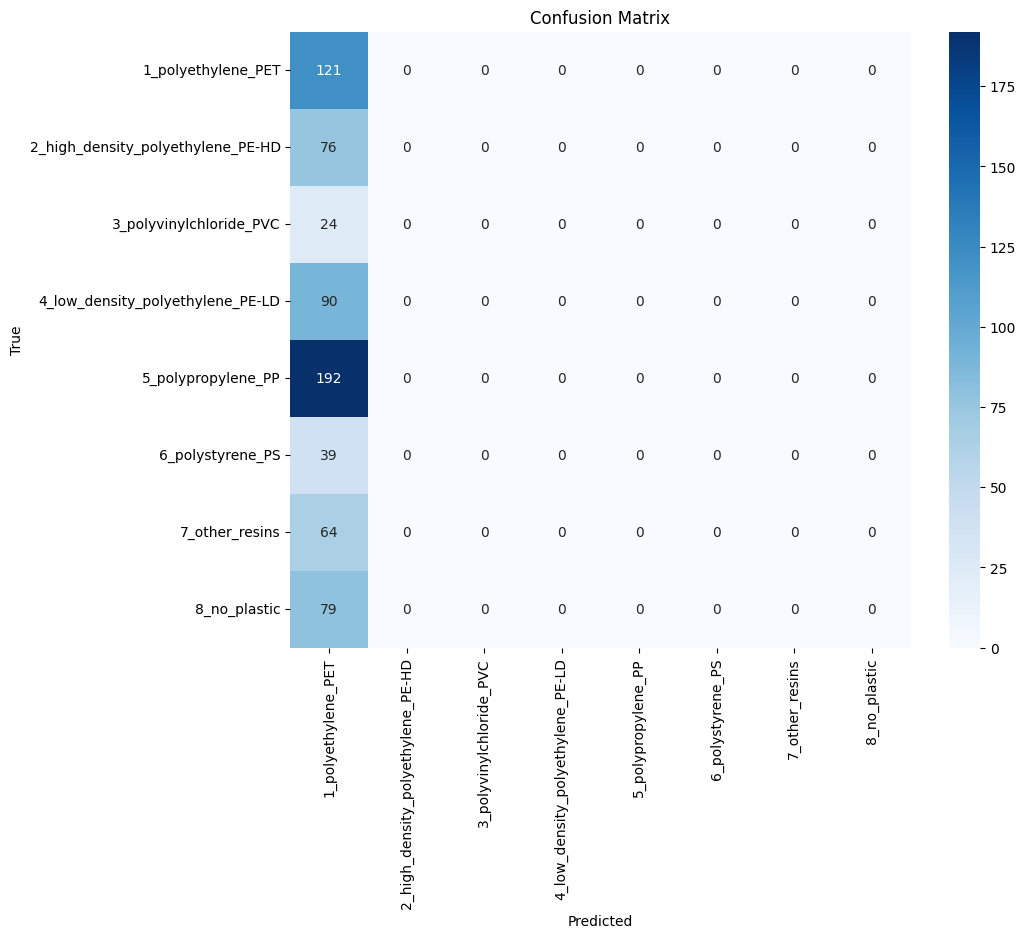

In [6]:

# After setting up the model (ViT + config + load state_dict)
evaluate_model(
    model=model,
    test_dataset_path="C:\\Users\\eric huang\\.cache\\kagglehub\\datasets\\piaoya\\plastic-recycling-codes\\versions\\9\\seven_plastics",
    classes=[
        '1_polyethylene_PET',
        '2_high_density_polyethylene_PE-HD',
        '3_polyvinylchloride_PVC',
        '4_low_density_polyethylene_PE-LD',
        '5_polypropylene_PP',
        '6_polystyrene_PS',
        '7_other_resins',
        '8_no_plastic'
    ],
    batch_size=64
)
